# Total Bars

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--update-ratio', '0.005', '--probe-ratio', '0.005', '--txn-count', '40', '--scan-count', '6', '--warehouse-count', '5', '--scan-reuse-ratio', '0.8', '--analytical-ratio', '0.6', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
probe ratio: 0.005
Analytical ratio: Some(0.6)
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 6

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.4)
Transactions Probe ratio: Some(0.24)
Transactions Scan ratio: Some(0.24)
Transactions Delta Scan ratio: Some(0.12)
-------------------------------------------------

,idx,tx_id,tx_type,repair_type,table_type,duration_ms,count,read_ts,from_ts,to_ts
0,0,0,InitLoad,No Repair,naive,90.406183,150000.0,NaN,NaN,NaN
1,0,0,InitLoad,Read Repair,naive,89.368083,150000.0,NaN,NaN,NaN
2,0,0,InitLoad,Write Repair,naive,89.676934,150000.0,NaN,NaN,NaN
3,1,1,MarkTs,No Repair,naive,117.079109,NaN,1.0,NaN,NaN
4,1,1,MarkTs,Read Repair,naive,117.109337,NaN,1.0,NaN,NaN
5,1,1,MarkTs,Write Repair,naive,116.300394,NaN,1.0,NaN,NaN
6,2,2,Scan,No Repair,naive,72.717879,NaN,1.0,NaN,NaN
7,2,2,Scan,Read Repair,naive,83.840547,NaN,1.0,NaN,NaN
8,2,2,Scan,Write Repair,naive,85.439411,NaN,1.0,NaN,NaN
9,3,3,Probe,No Repair,naive,127.520947,750.0,1.0,NaN,NaN


duration_max: 320.594528


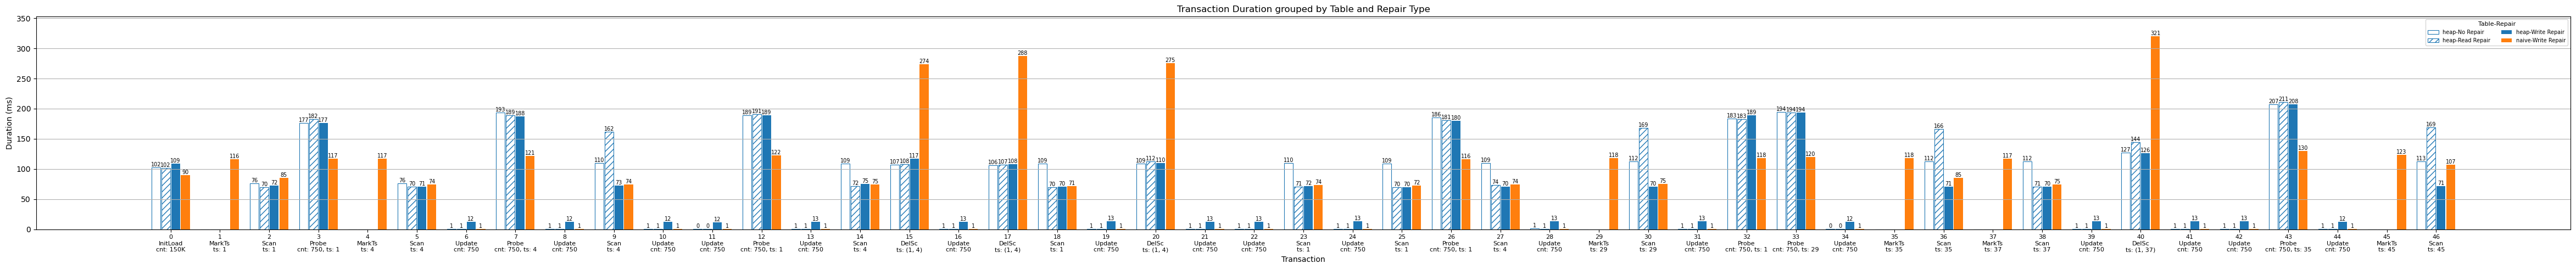

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--update-ratio", "0.005",  # update ratio, % of base table
    "--probe-ratio", "0.0005",
    "--txn-count", "40",  
    "--scan-count", "6",  # delta scan count
    "--warehouse-count", "5", # linear to base table size
    "--scan-reuse-ratio", "0.8",
    "--analytical-ratio", "0.6"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap"] # , "par", "chain"

def prepare_bar_style(repair_type, table_type, color_map, repair_hatches):
    if repair_type == "Write Repair":
        return {
            'facecolor': color_map[table_type],
            'edgecolor': color_map[table_type],
            'hatch': '',
            'linewidth': 0
        }
    else:
        return {
            'facecolor': 'white',
            'edgecolor': color_map[table_type],
            'hatch': repair_hatches.get(repair_type, ''),
            'linewidth': 0.8
        }
def draw_bar_labels(ax, x_positions, heights, font_size=7):
    for x, y in zip(x_positions, heights):
        if y > 0:  
            ax.text(
                x, 
                y, 
                f"{y:.0f}", 
                ha='center', 
                va='bottom', 
                fontsize=font_size
            )
from bench_script_functions import prepare_plot_data
def plot_all(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, _ = prepare_plot_data(df)

    fig, ax = plt.subplots(figsize=(max(8, len(unique_idx) * 1.0), 5))

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    num_bars_per_group = len(groups)
    group_width = 0.8
    bar_width = group_width / num_bars_per_group

    idx_to_pos = {idx: pos for pos, idx in enumerate(unique_idx)}

    duration_max = 0.0
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        x_positions = []
        durations = []

        for idx in unique_idx:
            x_pos = idx_to_pos[idx] + (i - num_bars_per_group/2) * bar_width + bar_width/2
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            x_positions.append(x_pos)
            durations.append(duration)

        style = prepare_bar_style(repair_type, table_type, color_map, repair_hatches)

        ax.bar(
            x_positions,
            durations,
            width=bar_width * 0.9,
            label=f"{table_type}-{repair_type}",
            **style
        )
        duration_max = max(duration_max, max(durations))
        draw_bar_labels(ax, x_positions, durations)

  
    print(f"duration_max: {duration_max}")
    max_y = duration_max * 1.1
    ax.set_ylim(0, max_y)

    ax.set_xticks(range(len(unique_idx)))
    ax.set_xticklabels(x_labels, rotation=0, fontsize=8, ha='center')

    ax.set_xlabel('Transaction')
    ax.set_ylabel('Duration (ms)')
    ax.set_title(f'Transaction Duration grouped by Table and Repair Type')

    plt.grid(True, axis='y')

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Table-Repair", fontsize=7, title_fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()
from bench_script_functions import run_and_collect
df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
display(df)
plot_all(df)



# Space Statistics -- Lots of Snapshots

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--txn-count', '60', '--warehouse-count', '40', '--analytical-ratio', '0.7', '--scan-reuse-ratio', '0.3', '--txn-gc-ratio', '0.03', '--space-stat', 'on', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: Some(0.7)
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.29100000000000004)
Transactions Probe ratio: Some(0.2716)
Transactions Scan ratio: Some(0.2716)
Transactions Delta Scan ratio: Some(0.135

,tx_type,count,percentage
0,DeltaScan,8,9.756098
1,GbgCollect,2,2.439024
2,HistoryScan,4,4.878049
3,InitLoad,1,1.219512
4,MarkTs,17,20.731707
5,Probe,16,19.512195
6,RecentScan,15,18.292683
7,Update,19,23.170732


-----------------------------------------------------------------------
Hash table type: Heap
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: Some(0.7)
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.29100000000000004)
Transactions Probe ratio: Some(0.2716)
Transactions Scan ratio: Some(0.2716)
Transactions Delta Scan ratio: Some(0.13579999999999995)
Transactions GC ratio: Some(0.03)
Transactions Scan Reuse ratio: 0.3
-----------------------------------------------------------------------


txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1200000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 3600
idx:   3, tx_id:   3, tx_ts:   3, t

,table_type,repair_type,total_space,all_versions_space,valid_space
0,naive,No Repair,15749087232,14606400000,859200000
1,heap,No Repair,997195776,905596800,859200000
2,par,No Repair,1517289472,905596800,859200000
3,chain,No Repair,1014235136,905596800,859200000


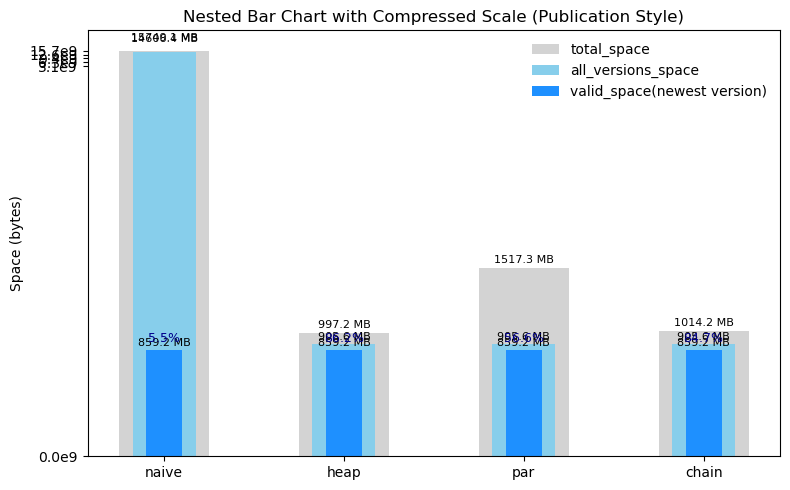

In [20]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")

TITLE = "(UNIFORM-ANALYTICAL) LOTS_OF_SNAPSHOTS"

BASE_ARGS = [
    "--update-ratio", "0.003",  # update ratio, % of base table
    "--probe-ratio", "0.0001",
    "--txn-count", "60",  
    "--warehouse-count", "40", # linear to base table size
    "--analytical-ratio", "0.7",
    "--scan-reuse-ratio", "0.3",
    "--txn-gc-ratio", "0.03"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"] # , "par", "chain"

from bench_script_functions import run_and_collect_space
new_args = BASE_ARGS + ["--space-stat", "on"]

df = run_and_collect_space(BIN, TABLE_TYPES, new_args, REPEAT)

# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
display(df)

def plot_nested_space(df):
#     for col in ["total_space", "all_versions_space", "valid_space"]:
#         df[col] = pd.to_numeric(df[col], errors="coerce")

#     df["all_versions_ratio"] = df["all_versions_space"] / df["total_space"]
#     df["valid_ratio"] = df["valid_space"] / df["total_space"]

#     fig, ax = plt.subplots(figsize=(8,6))
#     bar_width = 0.5

#     ax.bar(df["table_type"], df["total_space"], 
#            color="lightgray", width=bar_width, label="total_space")
#     ax.bar(df["table_type"], df["all_versions_space"], 
#            color="skyblue", width=bar_width*0.7, label="all_versions_space")
#     ax.bar(df["table_type"], df["valid_space"], 
#            color="dodgerblue", width=bar_width*0.4, label="valid_space(newest version)")

#     for i, row in df.iterrows():
#         total_mb = row["total_space"] / 1e6
#         all_versions_mb = row["all_versions_space"] / 1e6
#         valid_mb = row["valid_space"] / 1e6

#         ax.text(i - 0.2, row["total_space"] * 1.02, f"{total_mb:.1f} MB", 
#                 ha="center", va="center", fontsize=8, color="black")
#         ax.text(i - 0.2, row["all_versions_space"] * 1.02, f"{all_versions_mb:.1f} MB", 
#                 ha="center", va="center", fontsize=8, color="black")
#         ax.text(i - 0.2, row["valid_space"] * 1.02, f"{valid_mb:.1f} MB", 
#                 ha="center", va="center", fontsize=8, color="black")

#         ax.text(i + 0.2, row["all_versions_space"] * 1.02,
#                 f"{row['all_versions_ratio']:.1%}", 
#                 ha="center", va="bottom", fontsize=9, color="blue")
#         ax.text(i + 0.2, row["valid_space"] * 1.02,
#                 f"{row['valid_ratio']:.1%}", 
#                 ha="center", va="bottom", fontsize=9, color="darkblue")

#     ax.set_ylabel("Space (bytes)")
#     max_value = df[["total_space", "all_versions_space", "valid_space"]].values.max()
#     ax.set_ylim(0, max_value * 1.15)
#     ax.set_title("Nested Bar Chart with Ratios and Sizes (MB)")
#     ax.legend()
#     plt.tight_layout()
#     plt.show()
# import matplotlib.pyplot as plt
# import pandas as pd

# def plot_nested_space_broken_axis(df):
    for col in ["total_space", "all_versions_space", "valid_space"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["all_versions_ratio"] = df["all_versions_space"] / df["total_space"]
    df["valid_ratio"] = df["valid_space"] / df["total_space"]

    fig, ax = plt.subplots(figsize=(8, 5))
    bar_width = 0.5

    # 计算压缩后的高度（非线性映射）
    def compress_y(y):
        """科研风格：线性区 + 压缩区"""
        threshold = df["total_space"].max() * 0.2
        if y <= threshold:
            return y
        else:
            # 超过阈值部分压缩（平滑过渡）
            return threshold + (y - threshold) * 0.01

    compress = np.vectorize(compress_y)

    # 绘制柱状图
    ax.bar(df["table_type"], compress(df["total_space"]), 
           color="lightgray", width=bar_width, label="total_space")
    ax.bar(df["table_type"], compress(df["all_versions_space"]), 
           color="skyblue", width=bar_width*0.7, label="all_versions_space")
    ax.bar(df["table_type"], compress(df["valid_space"]), 
           color="dodgerblue", width=bar_width*0.4, label="valid_space(newest version)")

    # 添加文字标注（保持真实比例）
    for i, row in df.iterrows():
        total_mb = row["total_space"] / 1e6
        all_mb = row["all_versions_space"] / 1e6
        valid_mb = row["valid_space"] / 1e6

        ax.text(i, compress(row["total_space"]) * 1.02, f"{total_mb:.1f} MB",
                ha="center", va="bottom", fontsize=8, color="black")
        ax.text(i, compress(row["all_versions_space"]) * 1.02, f"{all_mb:.1f} MB",
                ha="center", va="bottom", fontsize=8, color="black")
        ax.text(i, compress(row["valid_space"]) * 1.02, f"{valid_mb:.1f} MB",
                ha="center", va="bottom", fontsize=8, color="black")

        ax.text(i, compress(row["valid_space"]) * 1.05, f"{row['valid_ratio']:.1%}",
                ha="center", va="bottom", fontsize=9, color="darkblue")

    # Y 轴刻度显示真实数值（反向映射）
    yticks_raw = np.linspace(0, df["total_space"].max(), 6)
    yticks_compressed = [compress_y(y) for y in yticks_raw]
    ax.set_yticks(yticks_compressed)
    ax.set_yticklabels([f"{y/1e9:.1f}e9" for y in yticks_raw])

    ax.set_ylabel("Space (bytes)")
    ax.set_title("Nested Bar Chart with Compressed Scale (Publication Style)")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

plot_nested_space(df)
df.to_csv(f'output/{TITLE}_spaceStatistics_result.csv', index=False)



# Space Statistics -- Reuse Snapshots

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")

TITLE = "(UNIFORM-ANALYTICAL) REUSE_OF_SNAPSHOTS"

BASE_ARGS = [
    "--update-ratio", "0.003",  # update ratio, % of base table
    "--probe-ratio", "0.0001",
    "--txn-count", "60",  
    "--warehouse-count", "35", # linear to base table size
    "--analytical-ratio", "0.7",
    "--txn-gc-ratio", "0.03"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap" , "par", "chain"] # , "par", "chain"

from bench_script_functions import run_and_collect_space
new_args = BASE_ARGS + ["--space-stat", "on"]

df = run_and_collect_space(BIN, TABLE_TYPES, new_args, REPEAT)

# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
display(df)

def plot_nested_space(df):
    for col in ["total_space", "all_versions_space", "valid_space"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["all_versions_ratio"] = df["all_versions_space"] / df["total_space"]
    df["valid_ratio"] = df["valid_space"] / df["total_space"]

    fig, ax = plt.subplots(figsize=(8,6))
    bar_width = 0.5

    ax.bar(df["table_type"], df["total_space"], 
           color="lightgray", width=bar_width, label="total_space")
    ax.bar(df["table_type"], df["all_versions_space"], 
           color="skyblue", width=bar_width*0.7, label="all_versions_space")
    ax.bar(df["table_type"], df["valid_space"], 
           color="dodgerblue", width=bar_width*0.4, label="valid_space(newest version)")

    for i, row in df.iterrows():
        total_mb = row["total_space"] / 1e6
        all_versions_mb = row["all_versions_space"] / 1e6
        valid_mb = row["valid_space"] / 1e6

        ax.text(i - 0.2, row["total_space"] * 1.02, f"{total_mb:.1f} MB", 
                ha="center", va="center", fontsize=8, color="black")
        ax.text(i - 0.2, row["all_versions_space"] * 1.02, f"{all_versions_mb:.1f} MB", 
                ha="center", va="center", fontsize=8, color="black")
        ax.text(i - 0.2, row["valid_space"] * 1.02, f"{valid_mb:.1f} MB", 
                ha="center", va="center", fontsize=8, color="black")

        ax.text(i + 0.2, row["all_versions_space"] * 1.02,
                f"{row['all_versions_ratio']:.1%}", 
                ha="center", va="bottom", fontsize=9, color="blue")
        ax.text(i + 0.2, row["valid_space"] * 1.02,
                f"{row['valid_ratio']:.1%}", 
                ha="center", va="bottom", fontsize=9, color="darkblue")

    ax.set_ylabel("Space (bytes)")
    max_value = df[["total_space", "all_versions_space", "valid_space"]].values.max()
    ax.set_ylim(0, max_value * 1.15)
    ax.set_title("Nested Bar Chart with Ratios and Sizes (MB)")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_nested_space(df)
df.to_csv(f'output/{TITLE}_spaceStatistics_result.csv', index=False)


=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--txn-count', '60', '--warehouse-count', '35', '--analytical-ratio', '0.7', '--scan-reuse-ratio', '0.2', '--txn-gc-ratio', '0.03', '--space-stat', 'on', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: Some(0.7)
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.27)
Transactions Probe ratio: Some(0.27999999999999997)
Transactions Scan ratio: Some(0.27999999999999997)
Transactions Delta Scan ratio:

# Stacked Bar Chart -- Analytical Only

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--analytical-uniform', 'on', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--analytical-ratio', '1.0', '--txn-gc-ratio', '0.05', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: Some(1.0)
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.0)
Transactions Probe ratio: Some(0.2375)
Transactions Scan ratio: Some(0.475)
Transactions Delta Scan ratio: Some(0.2375)
Transactions GC ratio: Some(0.05)
T

,tx_type,count
0,DelSc,14
1,GbgCollect,3
2,HistoryScan,17
3,InitLoad,1
4,MarkTs,16
5,Probe,14
6,RecentScan,14


,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,14300.534073
1,chain,Write Repair,GbgCollect,0.173379
2,chain,Write Repair,HistoryScan,11620.701376
3,chain,Write Repair,InitLoad,767.054066
4,chain,Write Repair,MarkTs,0.000000
5,chain,Write Repair,Probe,2541.649268
6,chain,Write Repair,RecentScan,9795.152025
7,heap,No Repair,DelSc,14797.278646
8,heap,No Repair,GbgCollect,812.946703
9,heap,No Repair,HistoryScan,13388.579284


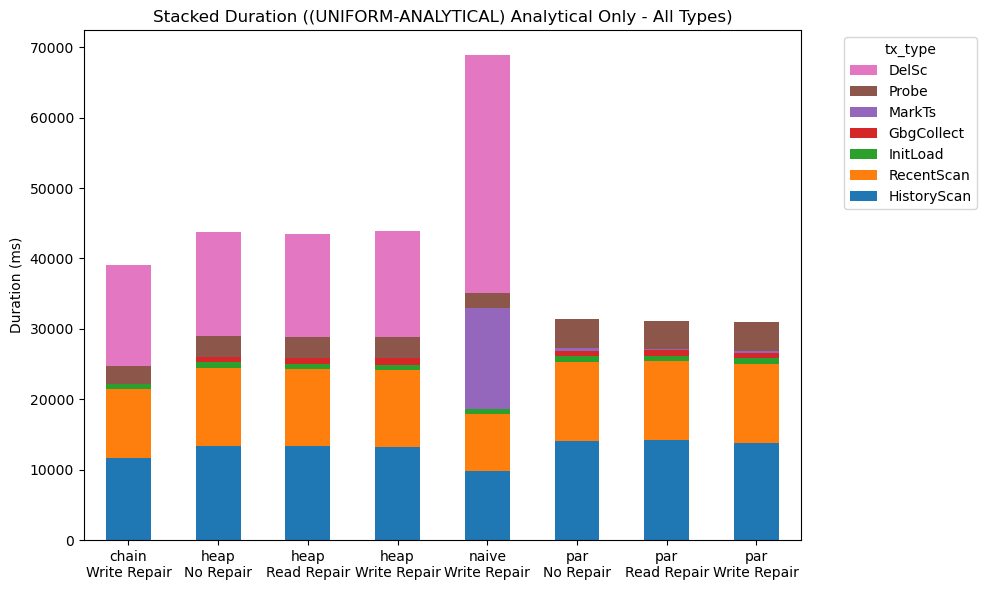

In [6]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "(UNIFORM-ANALYTICAL) Analytical Only"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "60",
    "--warehouse-count", "35", # linear to base table size
    "--analytical-uniform", "on"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"] # , "par", "chain"

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar, plot_stack_bar_chart

added_args = [
    "--update-ratio", "0.003",  # update ratio, 0.3% of base table
    "--probe-ratio", "0.0001",
    "--analytical-ratio", "1.0",
    "--txn-gc-ratio", "0.05"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_stack_bar_chart(df, title=TITLE)




# Stacked Bar Chart -- Extremely Analytical

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--analytical-uniform', 'on', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--analytical-ratio', '0.95', '--txn-gc-ratio', '0.05', '--table-type', 'naive']


-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: Some(0.95)
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.04750000000000004)
Transactions Probe ratio: Some(0.225625)
Transactions Scan ratio: Some(0.45125)
Transactions Delta Scan ratio: Some(0.225625)
Transactions GC ratio: Some(0.05)
Transactions Scan Reuse ratio: 0.5
-----------------------------------------------------------------------


txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     MarkTs, Mark Ts: 2
idx:   3, tx_id:   3, tx_ts:   3, tx_type: Recent

,tx_type,count
0,DelSc,14
1,GbgCollect,3
2,HistoryScan,12
3,InitLoad,1
4,MarkTs,18
5,Probe,14
6,RecentScan,16
7,Update,3


,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,14947.281539
1,chain,Write Repair,GbgCollect,0.382148
2,chain,Write Repair,HistoryScan,9531.339579
3,chain,Write Repair,InitLoad,753.573560
4,chain,Write Repair,MarkTs,0.000000
5,chain,Write Repair,Probe,2674.787183
6,chain,Write Repair,RecentScan,11407.827915
7,chain,Write Repair,Update,273.083602
8,heap,No Repair,DelSc,16035.422386
9,heap,No Repair,GbgCollect,884.656004


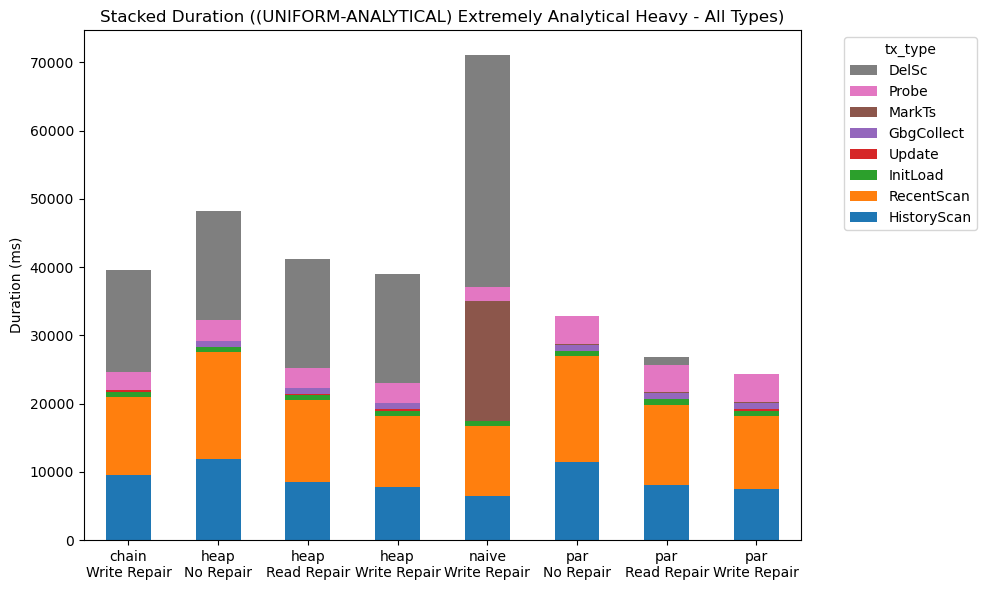

In [7]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "(UNIFORM-ANALYTICAL) Extremely Analytical Heavy"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "60",
    "--warehouse-count", "35", # linear to base table size
    "--analytical-uniform", "on"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"] # , "par", "chain"

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar, plot_stack_bar_chart

added_args = [
    "--update-ratio", "0.003",  # update ratio, 0.3% of base table
    "--probe-ratio", "0.0001",
    "--analytical-ratio", "0.95",
    "--txn-gc-ratio", "0.05"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_stack_bar_chart(df, title=TITLE)




# Stacked Bar Chart -- analytical

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--analytical-uniform', 'on', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--analytical-ratio', '0.80', '--txn-gc-ratio', '0.05', '--table-type', 'naive']


-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: Some(0.8)
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.18999999999999995)
Transactions Probe ratio: Some(0.19)
Transactions Scan ratio: Some(0.38)
Transactions Delta Scan ratio: Some(0.19)
Transactions GC ratio: Some(0.05)
Transactions Scan Reuse ratio: 0.5
-----------------------------------------------------------------------


txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 3150
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     MarkTs

,tx_type,count
0,DelSc,11
1,GbgCollect,3
2,HistoryScan,14
3,InitLoad,1
4,MarkTs,14
5,Probe,11
6,RecentScan,12
7,Update,13


,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,12848.704958
1,chain,Write Repair,GbgCollect,0.919773
2,chain,Write Repair,HistoryScan,9144.713868
3,chain,Write Repair,InitLoad,743.004622
4,chain,Write Repair,MarkTs,0.000000
5,chain,Write Repair,Probe,1689.864004
6,chain,Write Repair,RecentScan,7822.394575
7,chain,Write Repair,Update,1295.000808
8,heap,No Repair,DelSc,13821.087023
9,heap,No Repair,GbgCollect,873.181758


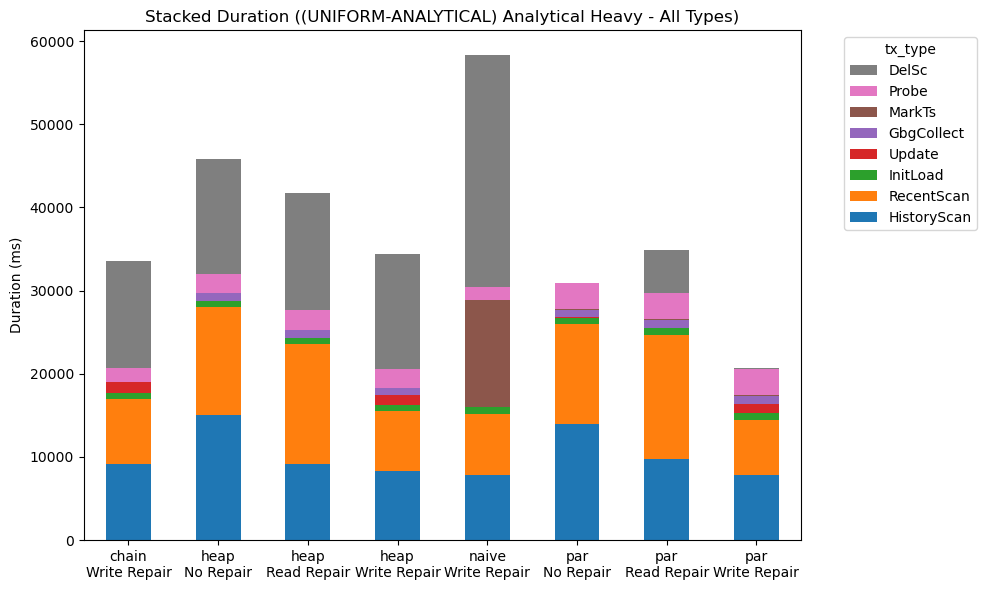

In [8]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "(UNIFORM-ANALYTICAL) Analytical Heavy"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "60",  
    "--warehouse-count", "35", # linear to base table size
    "--analytical-uniform", "on"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"] #, "par", "chain"

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar, plot_stack_bar_chart

added_args = [
    "--update-ratio", "0.003",  # update ratio, 0.3% of base table
    "--probe-ratio", "0.0001",
    "--analytical-ratio", "0.80",
    "--txn-gc-ratio", "0.05"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_stack_bar_chart(df, title=TITLE)




# Stacked Bar Chart -- Hybrid

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--analytical-uniform', 'on', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--analytical-ratio', '0.50', '--txn-gc-ratio', '0.05', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: Some(0.5)
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.475)
Transactions Probe ratio: Some(0.11875)
Transactions Scan ratio: Some(0.2375)
Transactions Delta Scan ratio: Some(0.11875)
Transactions GC ratio: Some(0

,tx_type,count
0,DelSc,7
1,GbgCollect,3
2,HistoryScan,10
3,InitLoad,1
4,MarkTs,8
5,Probe,7
6,RecentScan,6
7,Update,31


,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,8691.240515
1,chain,Write Repair,GbgCollect,1.864104
2,chain,Write Repair,HistoryScan,6520.305398
3,chain,Write Repair,InitLoad,752.288689
4,chain,Write Repair,MarkTs,0.001031
5,chain,Write Repair,Probe,1050.110254
6,chain,Write Repair,RecentScan,3966.412386
7,chain,Write Repair,Update,2836.672265
8,heap,No Repair,DelSc,9052.255596
9,heap,No Repair,GbgCollect,889.681260


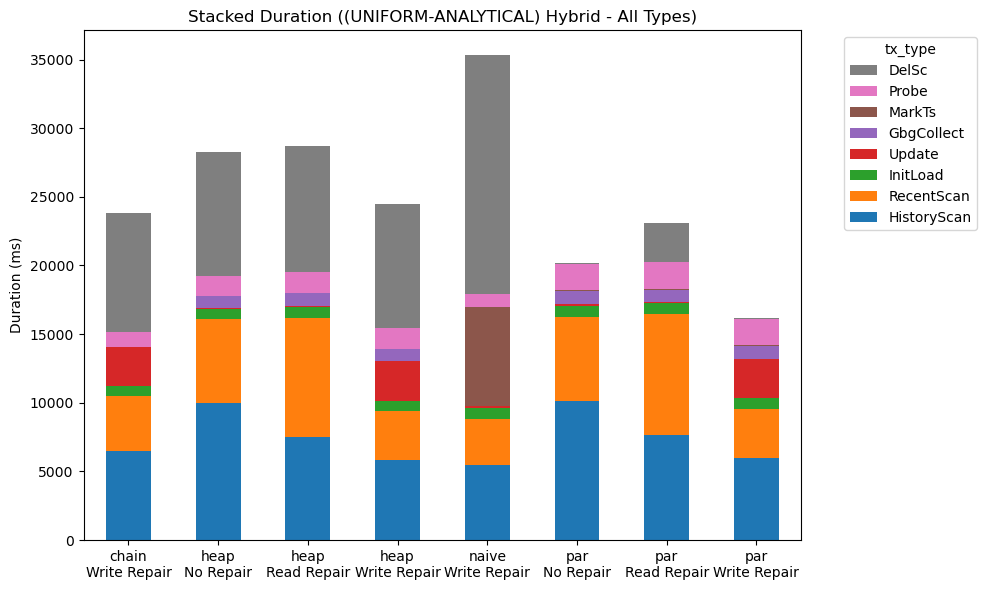

In [9]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "(UNIFORM-ANALYTICAL) Hybrid"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "60",  
    "--warehouse-count", "35", # linear to base table size
    "--analytical-uniform", "on"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap", "par", "chain"] #, "par", "chain"

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar, plot_stack_bar_chart

added_args = [
    "--update-ratio", "0.003",  # update ratio, 0.3% of base table
    "--probe-ratio", "0.0001",
    "--analytical-ratio", "0.50",
    "--txn-gc-ratio", "0.05"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_stack_bar_chart(df, title=TITLE)




# Stacked Bar Chart -- Transactional

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--analytical-uniform', 'on', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--analytical-ratio', '0.20', '--txn-gc-ratio', '0.05', '--table-type', 'naive']


-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: Some(0.2)
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.76)
Transactions Probe ratio: Some(0.0475)
Transactions Scan ratio: Some(0.095)
Transactions Delta Scan ratio: Some(0.0475)
Transactions GC ratio: Some(0.05)
Transactions Scan Reuse ratio: 0.5
-----------------------------------------------------------------------


txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 3150
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     MarkTs, Mark Ts:

,tx_type,count
0,DelSc,3
1,GbgCollect,3
2,HistoryScan,3
3,InitLoad,1
4,MarkTs,5
5,Probe,3
6,RecentScan,2
7,Update,48


,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,3599.324920
1,chain,Write Repair,GbgCollect,2.447586
2,chain,Write Repair,HistoryScan,1995.518560
3,chain,Write Repair,InitLoad,772.414612
4,chain,Write Repair,MarkTs,0.000000
5,chain,Write Repair,Probe,527.794118
6,chain,Write Repair,RecentScan,1296.434570
7,chain,Write Repair,Update,4370.470474
8,heap,No Repair,DelSc,3647.240113
9,heap,No Repair,GbgCollect,897.305200


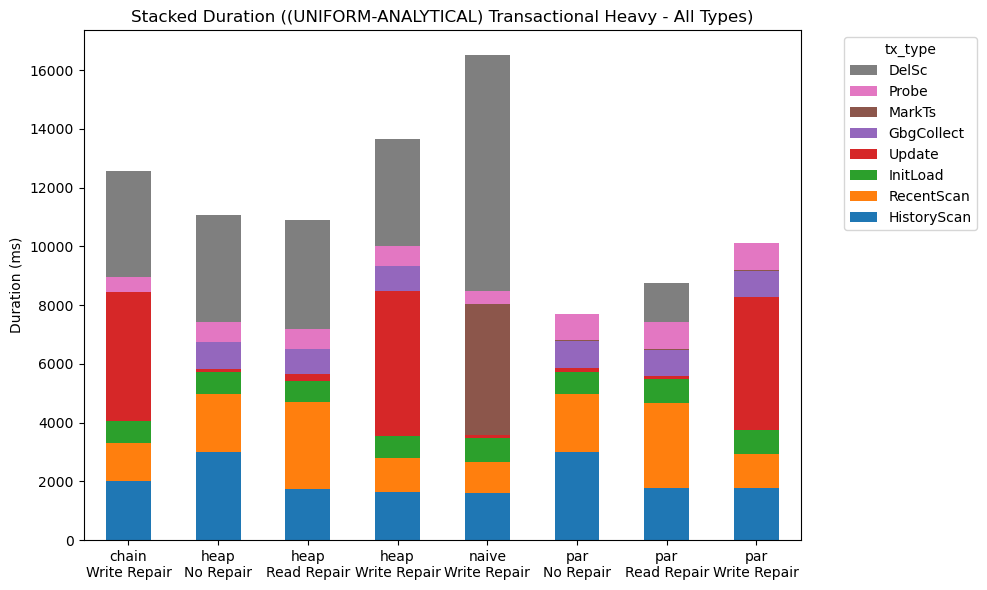

In [10]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "(UNIFORM-ANALYTICAL) Transactional Heavy"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "60",  
    "--warehouse-count", "35", # linear to base table size
    "--analytical-uniform", "on"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap", "par", "chain"] #, "par", "chain"

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar, plot_stack_bar_chart

added_args = [
    "--update-ratio", "0.003",  # update ratio, 0.3% of base table
    "--probe-ratio", "0.0001",
    "--analytical-ratio", "0.20",
    "--txn-gc-ratio", "0.05"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_stack_bar_chart(df, title=TITLE)




# Stacked Bar Chart -- Extremely Transactional

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--analytical-uniform', 'on', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--analytical-ratio', '0.05', '--txn-gc-ratio', '0.05', '--table-type', 'naive']


-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: Some(0.05)
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.9025)
Transactions Probe ratio: Some(0.011875)
Transactions Scan ratio: Some(0.02375)
Transactions Delta Scan ratio: Some(0.011875)
Transactions GC ratio: Some(0.05)
Transactions Scan Reuse ratio: 0.5
-----------------------------------------------------------------------


txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 3150
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     MarkTs,

,tx_type,count
0,DelSc,1
1,GbgCollect,1
2,HistoryScan,1
3,InitLoad,1
4,MarkTs,3
5,Probe,1
6,Update,56


,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,1163.176214
1,chain,Write Repair,GbgCollect,0.658860
2,chain,Write Repair,HistoryScan,712.333025
3,chain,Write Repair,InitLoad,761.244443
4,chain,Write Repair,MarkTs,0.000000
5,chain,Write Repair,Probe,178.731475
6,chain,Write Repair,Update,5071.297932
7,heap,No Repair,DelSc,1199.952708
8,heap,No Repair,GbgCollect,295.073487
9,heap,No Repair,HistoryScan,1022.755818


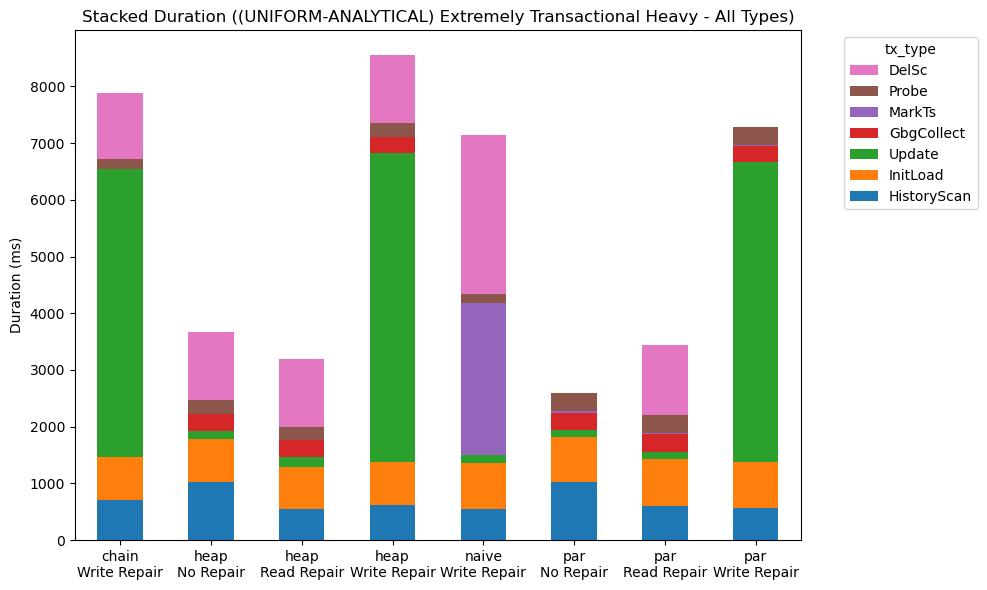

In [11]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "(UNIFORM-ANALYTICAL) Extremely Transactional Heavy"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "60",  
    "--warehouse-count", "35", # linear to base table size
    "--analytical-uniform", "on"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap", "par", "chain"] #, "par", "chain"

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar, plot_stack_bar_chart

added_args = [
    "--update-ratio", "0.003",  # update ratio, 0.3% of base table
    "--probe-ratio", "0.0001",
    "--analytical-ratio", "0.05",
    "--txn-gc-ratio", "0.05"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_stack_bar_chart(df, title=TITLE)




# Stacked Bar Chart -- Transactional Only

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--analytical-uniform', 'on', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--analytical-ratio', '0.0', '--txn-gc-ratio', '0.05', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: Some(0.0)
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.95)
Transactions Probe ratio: Some(0.0)
Transactions Scan ratio: Some(0.0)
Transactions Delta Scan ratio: Some(0.0)
Transactions GC ratio: Some(0.05)
Transact

,tx_type,count
0,GbgCollect,1
1,InitLoad,1
2,MarkTs,3
3,Update,59


,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,GbgCollect,0.670271
1,chain,Write Repair,InitLoad,744.435018
2,chain,Write Repair,MarkTs,0.000000
3,chain,Write Repair,Update,5264.254047
4,heap,No Repair,GbgCollect,296.848923
5,heap,No Repair,InitLoad,779.297457
6,heap,No Repair,MarkTs,0.000000
7,heap,No Repair,Update,162.750280
8,heap,Read Repair,GbgCollect,290.242769
9,heap,Read Repair,InitLoad,760.940481


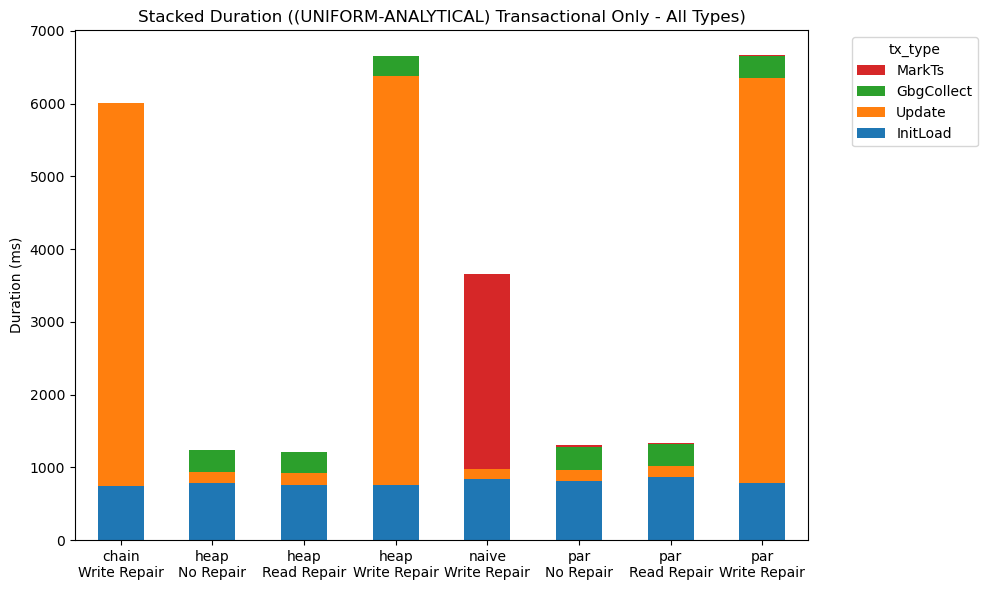

In [12]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "(UNIFORM-ANALYTICAL) Transactional Only"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "60",
    "--warehouse-count", "35", # linear to base table size
    "--analytical-uniform", "on"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap" , "par", "chain"] # , "par", "chain"

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar, plot_stack_bar_chart

added_args = [
    "--update-ratio", "0.003",  # update ratio, 0.3% of base table
    "--probe-ratio", "0.0001",
    "--analytical-ratio", "0.0",
    "--txn-gc-ratio", "0.05"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_stack_bar_chart(df, title=TITLE)




# Stacked Bar Chart  -- Extremely Reuse of Time

In [8]:
# import subprocess
# from pathlib import Path
# import pandas as pd
# import matplotlib.pyplot as plt
# import re

# TITLE = "(UNIFORM-ANALYTICAL) Transactional Extremely Heavy"

# # ----------------------------------------
# # Build the Rust binary
# # ----------------------------------------
# print("=== Building Rust binary in release mode ===")
# build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
# result = subprocess.run(build_cmd, capture_output=True, text=True)
# if result.returncode != 0:
#     print("[ERROR] cargo build failed.\n", result.stderr)
#     raise SystemExit(1)
# print("Cargo build completed successfully.\n")


# BASE_ARGS = [
#     "--txn-count", "40",  
#     "--warehouse-count", "5" # linear to base table size
# ]
# REPEAT=1
# BIN = Path("../../../target/release/htap_wkld")
# TABLE_TYPES = [ "naive", "heap"]

# from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar, plot_stack_bar_chart

# def plot_stack_bar_chart(df, title=TITLE):
#     color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

#     groups = []
#     for table_type in table_types:
#         if table_type in ["chain", "naive"]:
#             groups.append((table_type, "Write Repair"))
#         else:
#             for repair_type in repair_types:
#                 groups.append((table_type, repair_type))

#     print(groups)
#     type_and_durations = []
#     for i, (table_type, repair_type) in enumerate(groups):
#         if table_type in ["chain", "naive"] and repair_type != "Write Repair":
#             continue

#         df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

#         scan_count = 0

#         for idx in unique_idx:
#             df_row = df_group[df_group['idx'] == idx]
#             duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
#             label = dict_labels[idx]
#             cur_tx_type = label['tx_type']

#             # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
#             line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
#             type_and_durations.append(line)
#     # print(type_and_durations)
#     df = pd.DataFrame(type_and_durations)

#     result = (
#         df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
#         .agg(duration_ms=("duration_ms", lambda x: x.sum())) # if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()
#     )
#     display(result)

#     draw_stack_bar(result, TITLE, "All Types")

# added_args = [
#     "--analytical-ratio", "0.9",
#     "--scan-count", "10",
#     "--delta-count", "2",
#     "--update-ratio", "0.005",  # update ratio, % of base table
#     "--probe-ratio", "0.01"
# ]

# df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# # Display the resulting DataFrame
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', None)
# pd.set_option('display.max_colwidth', None)
# plot_stack_bar_chart(df, title=TITLE)




# DELTA TRADEOFF -- delta scan

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '50', '--update-ratio', '0.003', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.2', '--txn-gc-ratio', '0.03', '--txn-probe-ratio', '0.385', '--txn-delta-ratio', '0.0', '--txn-scan-ratio', '0.385', '--table-type', 'naive']


-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 50
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.2)
Transactions Probe ratio: Some(0.385)
Transactions Scan ratio: Some(0.385)
Transactions Delta Scan ratio: Some(0.0)
-----------------------------------------------------------------------


txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 3150
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     MarkTs, Mark Ts: 3
idx:   4, tx_id:   4, tx_ts:   4, tx_type:     Update, Update count: 3150
id

,tx_type,count,percentage
0,GbgCollect,2,3.1250
1,HistoryScan,11,17.1875
2,InitLoad,1,1.5625
3,MarkTs,11,17.1875
4,Probe,19,29.6875
5,RecentScan,8,12.5000
6,Update,12,18.7500


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '50', '--update-ratio', '0.003', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.2', '--txn-gc-ratio', '0.03', '--txn-probe-ratio', '0.34500000000000003', '--txn-delta-ratio', '0.08', '--txn-scan-ratio', '0.34500000000000003', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 50
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.2)
Transactions Probe ratio: Some(0.34500000000000003)
Transactions Scan ratio: Some(0.34500000000000003)
Transactions Delta Scan ratio: Some(0.08)
-----------

,tx_type,count,percentage
0,DeltaScan,4,6.451613
1,GbgCollect,2,3.225806
2,HistoryScan,11,17.741935
3,InitLoad,1,1.612903
4,MarkTs,9,14.516129
5,Probe,17,27.419355
6,RecentScan,6,9.677419
7,Update,12,19.354839


...

,tx_type,count,percentage
0,DeltaScan,7,11.475410
1,GbgCollect,2,3.278689
2,HistoryScan,10,16.393443
3,InitLoad,1,1.639344
4,MarkTs,8,13.114754
5,Probe,16,26.229508
6,RecentScan,5,8.196721
7,Update,12,19.672131


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '50', '--update-ratio', '0.003', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.2', '--txn-gc-ratio', '0.03', '--txn-probe-ratio', '0.27', '--txn-delta-ratio', '0.23', '--txn-scan-ratio', '0.27', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 50
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.2)
Transactions Probe ratio: Some(0.27)
Transactions Scan ratio: Some(0.27)
Transactions Delta Scan ratio: Some(0.23)
-----------------------------------------------------------------------

,tx_type,count,percentage
0,DeltaScan,12,21.818182
1,GbgCollect,1,1.818182
2,HistoryScan,12,21.818182
3,InitLoad,1,1.818182
4,MarkTs,3,5.454545
5,Probe,14,25.454545
6,Update,12,21.818182


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '50', '--update-ratio', '0.003', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.2', '--txn-gc-ratio', '0.03', '--txn-probe-ratio', '0.23500000000000001', '--txn-delta-ratio', '0.3', '--txn-scan-ratio', '0.23500000000000001', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 50
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.2)
Transactions Probe ratio: Some(0.23500000000000001)
Transactions Scan ratio: Some(0.23500000000000001)
Transactions Delta Scan ratio: Some(0.3)
-------------

,tx_type,count,percentage
0,DeltaScan,15,26.315789
1,GbgCollect,2,3.508772
2,HistoryScan,10,17.543860
3,InitLoad,1,1.754386
4,MarkTs,4,7.017544
5,Probe,12,21.052632
6,RecentScan,1,1.754386
7,Update,12,21.052632


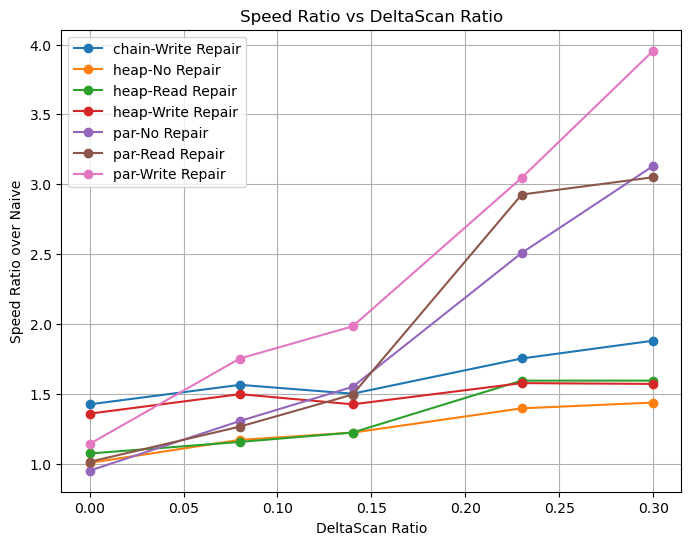

In [9]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "(UNIFORM-ANALYTICAL) DELTA_SCAN"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")

TXN_UPDATE_RATIO = 0.2
TXN_GC_RATIO = 0.03

BASE_ARGS = [
    "--txn-count", "50",  
    "--update-ratio", "0.003",
    "--warehouse-count", "35", # linear to base table size
    "--probe-ratio", "0.0001",
    "--txn-update-ratio", str(TXN_UPDATE_RATIO),
    "--txn-gc-ratio", str(TXN_GC_RATIO)
]

REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap", "par", "chain"] #, "par", "chain"
REUSE_CONFIGS = [0.00, 0.08, 0.14, 0.23, 0.30] # (txn_delta_ratio) # , 0.12, 0.16

from bench_script_functions import run_and_collect, display_all_txns
TRANSACTIONAL_TX_TYPE = ['InitLoad', 'Update']
ANALYTICAL_TX_TYPE = ['Probe', 'Scan', 'DeltaScan']

def get_avg(df):
    # display(df)
    table_types = sorted(df['table_type'].unique())
    repair_types = ["No Repair", "Read Repair", "Write Repair"]
    tx_type_groups = ["DeltaScan"]
    groups = []
    for table_type in table_types:
        if table_type in ['naive', 'chain']:
            groups.append((table_type, 'Write Repair'))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))
    
    durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]
        
        # DeltaScan only average
        # scan_vals = df_group['duration_ms'].values
        # avg_delta_scan = scan_vals.sum()
        # display(df_group)
        scan_vals = df_group['duration_ms'].sum()
        durations.append((table_type, repair_type, scan_vals)) # table_type, repair_type, avg_duration

        # display(df_group)
    return durations

# get ratio over base_type
def get_ratio(avg, base_type, txn_delta_ratio):
    result = []
    ratio_col_name = f'speed_ratio_over_{base_type}'
    base = None
    for (table_type, repair_type, avg_dur) in avg:
        if table_type in [base_type]:
            base = avg_dur
    
    for (table_type, repair_type, avg_dur) in avg:
        if table_type not in [base_type]:
            result.append({"txn_delta_ratio": txn_delta_ratio, "table_type": table_type, "repair_type": repair_type, ratio_col_name: base/ avg_dur})

    df_res = pd.DataFrame(result)
    return df_res
df_ratio = pd.DataFrame()
df_list = []
for txn_delta_ratio in REUSE_CONFIGS:
    analytical_ratio = 1.0 - TXN_UPDATE_RATIO - TXN_GC_RATIO
    assert (txn_delta_ratio < analytical_ratio)
    scan_and_probe = analytical_ratio - txn_delta_ratio
    txn_probe_ratio = scan_and_probe / 2
    txn_scan_ratio = scan_and_probe / 2
    appended_args = [
        "--txn-probe-ratio", str(txn_probe_ratio),
        "--txn-delta-ratio", str(txn_delta_ratio),
        "--txn-scan-ratio", str(txn_scan_ratio)
    ]


    NEW_ARGS = BASE_ARGS.copy()
    NEW_ARGS += appended_args
    
    df = run_and_collect(BIN, TABLE_TYPES, NEW_ARGS, REPEAT)
    display_all_txns(df)
    # Display the resulting DataFrame
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)
    result = df.groupby(["table_type", "repair_type", "tx_type"])["duration_ms"].sum().reset_index()
    df_avg = get_avg(result)
    # print(aa)
    ratio = get_ratio(df_avg, 'naive', txn_delta_ratio)
    df_ratio = pd.concat([df_ratio, ratio], ignore_index=True)
    # display(result)
    df_list.append(result)



df = df_ratio.sort_values(by="txn_delta_ratio")
df.to_csv(f'output/{TITLE}_result.csv', index=False)
# (table_type, repair_type) 
plt.figure(figsize=(8,6))
for (table, repair), group in df.groupby(["table_type", "repair_type"]):
    plt.plot(group["txn_delta_ratio"], group["speed_ratio_over_naive"], 
             marker='o', label=f"{table}-{repair}")

plt.xlabel("DeltaScan Ratio")
plt.ylabel("Speed Ratio over Naive")
plt.title("Speed Ratio vs DeltaScan Ratio")
plt.legend()
plt.grid(True)
plt.show()



# DELTA TRADEOFF -- update ratio (CONFIG)

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.003', '--txn-scan-ratio', '0.235', '--txn-probe-ratio', '0.235', '--txn-delta-ratio', '0.0', '--table-type', 'naive']


-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.235)
Transactions Scan ratio: Some(0.235)
Transactions Delta Scan ratio: Some(0.0)
-----------------------------------------------------------------------


txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 3150
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     MarkTs, Mark Ts: 3
idx:   4, tx_id:   4, tx_ts:   4, tx_type:     Update, Update count: 3150
idx

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,GbgCollect,1.012045
1,chain,No Repair,HistoryScan,8292.342264
2,chain,No Repair,InitLoad,805.210772
3,chain,No Repair,MarkTs,0.000000
4,chain,No Repair,Probe,2446.467433
5,chain,No Repair,RecentScan,1396.051238
6,chain,No Repair,Update,3290.612870
7,chain,Read Repair,GbgCollect,0.919293
8,chain,Read Repair,HistoryScan,8430.047745
9,chain,Read Repair,InitLoad,816.423560


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.008', '--txn-scan-ratio', '0.235', '--txn-probe-ratio', '0.235', '--txn-delta-ratio', '0.0', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.008
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.235)
Transactions Scan ratio: Some(0.235)
Transactions Delta Scan ratio: Some(0.0)
------------------------------------------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,GbgCollect,2.166395
1,chain,No Repair,HistoryScan,8787.746592
2,chain,No Repair,InitLoad,748.513052
3,chain,No Repair,MarkTs,0.000000
4,chain,No Repair,Probe,2618.261584
5,chain,No Repair,RecentScan,1565.818749
6,chain,No Repair,Update,3533.687277
7,chain,Read Repair,GbgCollect,2.126896
8,chain,Read Repair,HistoryScan,9326.450201
9,chain,Read Repair,InitLoad,846.598917


...

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.022', '--txn-scan-ratio', '0.235', '--txn-probe-ratio', '0.235', '--txn-delta-ratio', '0.0', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.022
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.235)
Transactions Scan ratio: Some(0.235)
Transactions Delta Scan ratio: Some(0.0)
------------------------------------------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,GbgCollect,5.532517
1,chain,No Repair,HistoryScan,8679.615510
2,chain,No Repair,InitLoad,915.429608
3,chain,No Repair,MarkTs,0.000000
4,chain,No Repair,Probe,3103.499068
5,chain,No Repair,RecentScan,1448.217226
6,chain,No Repair,Update,4833.396680
7,chain,Read Repair,GbgCollect,5.464511
8,chain,Read Repair,HistoryScan,9027.752613
9,chain,Read Repair,InitLoad,842.735330


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.03', '--txn-scan-ratio', '0.235', '--txn-probe-ratio', '0.235', '--txn-delta-ratio', '0.0', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.03
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.235)
Transactions Scan ratio: Some(0.235)
Transactions Delta Scan ratio: Some(0.0)
--------------------------------------------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,GbgCollect,7.285574
1,chain,No Repair,HistoryScan,9494.199289
2,chain,No Repair,InitLoad,818.117943
3,chain,No Repair,MarkTs,0.000000
4,chain,No Repair,Probe,3472.648722
5,chain,No Repair,RecentScan,1541.611799
6,chain,No Repair,Update,5902.453483
7,chain,Read Repair,GbgCollect,7.513142
8,chain,Read Repair,HistoryScan,10118.708832
9,chain,Read Repair,InitLoad,818.525835


,tx_type,count,percentage
0,GbgCollect,2,2.941176
1,HistoryScan,12,17.647059
2,InitLoad,1,1.470588
3,MarkTs,5,7.352941
4,Probe,14,20.588235
5,RecentScan,2,2.941176
6,Update,32,47.058824


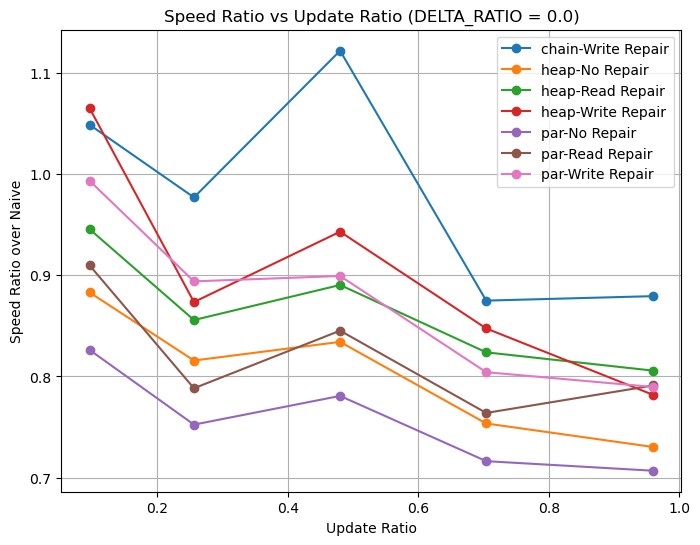

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.003', '--txn-scan-ratio', '0.185', '--txn-probe-ratio', '0.185', '--txn-delta-ratio', '0.1', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.185)
Transactions Scan ratio: Some(0.185)
Transactions Delta Scan ratio: Some(0.1)
------------------------------------------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,DeltaScan,8704.100516
1,chain,No Repair,GbgCollect,0.981439
2,chain,No Repair,HistoryScan,7214.786386
3,chain,No Repair,InitLoad,818.900235
4,chain,No Repair,MarkTs,0.000000
5,chain,No Repair,Probe,1948.890929
6,chain,No Repair,RecentScan,669.853281
7,chain,No Repair,Update,3099.226537
8,chain,Read Repair,DeltaScan,8795.311829
9,chain,Read Repair,GbgCollect,0.909245


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.008', '--txn-scan-ratio', '0.185', '--txn-probe-ratio', '0.185', '--txn-delta-ratio', '0.1', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.008
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.185)
Transactions Scan ratio: Some(0.185)
Transactions Delta Scan ratio: Some(0.1)
------------------------------------------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,DeltaScan,9386.228450
1,chain,No Repair,GbgCollect,2.136185
2,chain,No Repair,HistoryScan,6916.291414
3,chain,No Repair,InitLoad,910.688443
4,chain,No Repair,MarkTs,0.000000
5,chain,No Repair,Probe,2137.468164
6,chain,No Repair,RecentScan,738.013771
7,chain,No Repair,Update,3584.900066
8,chain,Read Repair,DeltaScan,9261.400083
9,chain,Read Repair,GbgCollect,2.179020


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.015', '--txn-scan-ratio', '0.185', '--txn-probe-ratio', '0.185', '--txn-delta-ratio', '0.1', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.015
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.185)
Transactions Scan ratio: Some(0.185)
Transactions Delta Scan ratio: Some(0.1)
------------------------------------------------

...

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.022', '--txn-scan-ratio', '0.185', '--txn-probe-ratio', '0.185', '--txn-delta-ratio', '0.1', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.022
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.185)
Transactions Scan ratio: Some(0.185)
Transactions Delta Scan ratio: Some(0.1)
------------------------------------------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,DeltaScan,9430.501152
1,chain,No Repair,GbgCollect,5.258628
2,chain,No Repair,HistoryScan,6972.591780
3,chain,No Repair,InitLoad,753.896841
4,chain,No Repair,MarkTs,0.005119
5,chain,No Repair,Probe,2192.473576
6,chain,No Repair,RecentScan,681.899561
7,chain,No Repair,Update,4634.463029
8,chain,Read Repair,DeltaScan,9430.228661
9,chain,Read Repair,GbgCollect,5.279298


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.03', '--txn-scan-ratio', '0.185', '--txn-probe-ratio', '0.185', '--txn-delta-ratio', '0.1', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.03
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.185)
Transactions Scan ratio: Some(0.185)
Transactions Delta Scan ratio: Some(0.1)
--------------------------------------------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,DeltaScan,9685.686891
1,chain,No Repair,GbgCollect,7.031699
2,chain,No Repair,HistoryScan,6622.290749
3,chain,No Repair,InitLoad,759.211029
4,chain,No Repair,MarkTs,0.000000
5,chain,No Repair,Probe,2311.648365
6,chain,No Repair,RecentScan,583.982863
7,chain,No Repair,Update,5214.507760
8,chain,Read Repair,DeltaScan,9684.123332
9,chain,Read Repair,GbgCollect,7.065833


,tx_type,count,percentage
0,DeltaScan,6,8.955224
1,GbgCollect,2,2.985075
2,HistoryScan,10,14.925373
3,InitLoad,1,1.492537
4,MarkTs,4,5.970149
5,Probe,11,16.417910
6,RecentScan,1,1.492537
7,Update,32,47.761194


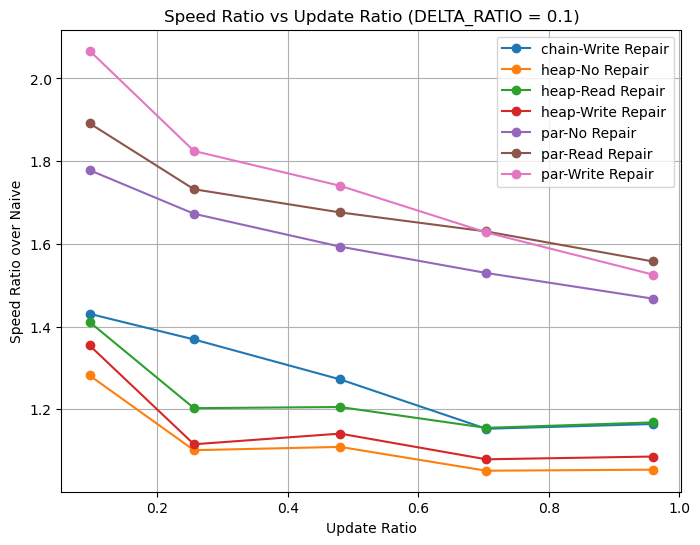

In [10]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")

TITLE = "(UNIFORM-ANALYTICAL) UPDATE"
TXN_UPDATE_RATIO = 0.5
TXN_GC_RATIO = 0.03
BASE_ARGS = [
    "--txn-count", "60",  
    "--warehouse-count", "35", # linear to base table size
    "--probe-ratio", "0.0001",
    "--txn-update-ratio", str(TXN_UPDATE_RATIO),
    "--txn-gc-ratio", str(TXN_GC_RATIO),
    "--seed", "74367232"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap", "par", "chain"] #, "par", "chain"
UPDATE_RATIOS = ["0.003", "0.008", "0.015", "0.022","0.03"] # , "0.015", "0.03"

from bench_script_functions import run_and_collect, display_all_txns
TRANSACTIONAL_TX_TYPE = ['InitLoad', 'Update']
ANALYTICAL_TX_TYPE = ['Probe', 'Scan', 'DeltaScan']

def get_avg(df):
    # display(df)
    table_types = sorted(df['table_type'].unique())
    repair_types = ["No Repair", "Read Repair", "Write Repair"]
    tx_type_groups = ["DeltaScan"]
    groups = []
    for table_type in table_types:
        if table_type in ['naive', 'chain']:
            groups.append((table_type, 'Write Repair'))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))
    
    durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]
        
        # DeltaScan only average
        # scan_vals = df_group['duration_ms'].values
        # avg_delta_scan = scan_vals.sum()
        # display(df_group)
        scan_vals = df_group['duration_ms'].sum()
        durations.append((table_type, repair_type, scan_vals)) # table_type, repair_type, avg_duration

        # display(df_group)
    return durations

# get ratio over base_type
def get_ratio(avg, base_type, update_ratio):
    result = []
    ratio_col_name = f'speed_ratio_over_{base_type}'
    base = None
    for (table_type, repair_type, avg_dur) in avg:
        if table_type in [base_type]:
            base = avg_dur
    
    for (table_type, repair_type, avg_dur) in avg:
        if table_type not in [base_type]:
            result.append({"update_ratio": update_ratio, "table_type": table_type, "repair_type": repair_type, ratio_col_name: base/ avg_dur})

    df_res = pd.DataFrame(result)
    return df_res

def run_and_draw(txn_delta_ratio):
    
    assert ((1.0 - TXN_UPDATE_RATIO - TXN_GC_RATIO) > (txn_delta_ratio - 1e-6))
    analytical_ratio = 1.0 - TXN_UPDATE_RATIO - TXN_GC_RATIO
    txn_probe_ratio = (analytical_ratio - txn_delta_ratio) / 2
    txn_scan_ratio = txn_probe_ratio
    appended_args = [
        "--txn-scan-ratio", str(txn_scan_ratio),
        "--txn-probe-ratio", str(txn_probe_ratio),
        "--txn-delta-ratio", str(txn_delta_ratio)
    ]
    df_ratio = pd.DataFrame()
    df_list = []
    update_count = 0
    last_df = None
    for update_ratio in UPDATE_RATIOS:
        NEW_ARGS = BASE_ARGS.copy()
        NEW_ARGS += ["--update-ratio", update_ratio]
        NEW_ARGS += appended_args
        
        df = run_and_collect(BIN, TABLE_TYPES, NEW_ARGS, REPEAT)
        update_count = (
            df[df["tx_type"] == "Update"]
            .groupby(["table_type", "repair_type"])
            .size()
            .iloc[0]   
        )
        # Display the resulting DataFrame
        pd.set_option('display.max_rows', None)
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', None)
        pd.set_option('display.max_colwidth', None)
        result = df.groupby(["table_type", "repair_type", "tx_type"])["duration_ms"].sum().reset_index()
        print(f"update_ratio: {update_ratio}")
        display(result)
        df_avg = get_avg(result)
        # print(aa)
        ratio = get_ratio(df_avg, 'naive', update_ratio)
        df_ratio = pd.concat([df_ratio, ratio], ignore_index=True)
        # display(result)
        df_list.append(result)
        last_df = df


    display_all_txns(last_df)



    df_ratio['update_ratio'] = df_ratio['update_ratio'].astype(float) * update_count
    # display(df_ratio)
    df = df_ratio.sort_values(by="update_ratio")
    df.to_csv(f'output/{TITLE}_deltaRatio{txn_delta_ratio}_result.csv', index=False)
    # 按 (table_type, repair_type) 分组画图
    plt.figure(figsize=(8,6))
    for (table, repair), group in df.groupby(["table_type", "repair_type"]):
        plt.plot(group["update_ratio"], group["speed_ratio_over_naive"], 
                marker='o', label=f"{table}-{repair}")

    plt.xlabel("Update Ratio")
    plt.ylabel("Speed Ratio over Naive")
    plt.title(f"Speed Ratio vs Update Ratio (DELTA_RATIO = {txn_delta_ratio})")
    plt.legend()
    plt.grid(True)
    plt.show()

run_and_draw(txn_delta_ratio=0.0)
run_and_draw(txn_delta_ratio=0.10)


# DELTA TRACEOFF -- reuse of snapshots (TBD)

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--warehouse-count', '35', '--txn-update-ratio', '0.3', '--txn-scan-ratio', '0.5', '--txn-gc-ratio', '0.03', '--scan-reuse-ratio', '0.1', '--txn-probe-ratio', '0.16999999999999996', '--txn-delta-ratio', '0.0', '--table-type', 'naive']


-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.3)
Transactions Probe ratio: Some(0.16999999999999996)
Transactions Scan ratio: Some(0.5)
Transactions Delta Scan ratio: Some(0.0)
-----------------------------------------------------------------------


txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 3150
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     MarkTs, Mark Ts: 3
idx:   4, tx_id:   4, tx_ts:   4, tx_type:     Update, Update co

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,GbgCollect,0.876015
1,chain,No Repair,HistoryScan,1345.940765
2,chain,No Repair,InitLoad,772.721089
3,chain,No Repair,MarkTs,0.000000
4,chain,No Repair,Probe,1624.751357
5,chain,No Repair,RecentScan,18455.905513
6,chain,No Repair,Update,1871.566684
7,chain,Read Repair,GbgCollect,0.870490
8,chain,Read Repair,HistoryScan,1361.274780
9,chain,Read Repair,InitLoad,746.771653


,tx_type,count,percentage
0,GbgCollect,2,2.127660
1,HistoryScan,2,2.127660
2,InitLoad,1,1.063830
3,MarkTs,31,32.978723
4,Probe,10,10.638298
5,RecentScan,28,29.787234
6,Update,20,21.276596


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--warehouse-count', '35', '--txn-update-ratio', '0.3', '--txn-scan-ratio', '0.5', '--txn-gc-ratio', '0.03', '--scan-reuse-ratio', '0.2', '--txn-probe-ratio', '0.16999999999999996', '--txn-delta-ratio', '0.0', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.3)
Transactions Probe ratio: Some(0.16999999999999996)
Transactions Scan ratio: Some(0.5)
Transactions Delta Scan ratio: Some(0.0)
----------------

...

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,GbgCollect,0.920599
1,chain,No Repair,HistoryScan,14574.226066
2,chain,No Repair,InitLoad,749.493335
3,chain,No Repair,MarkTs,0.000000
4,chain,No Repair,Probe,1617.022746
5,chain,No Repair,RecentScan,5312.212951
6,chain,No Repair,Update,1891.830468
7,chain,Read Repair,GbgCollect,0.906669
8,chain,Read Repair,HistoryScan,14616.815299
9,chain,Read Repair,InitLoad,742.843109


,tx_type,count,percentage
0,GbgCollect,2,2.702703
1,HistoryScan,22,29.729730
2,InitLoad,1,1.351351
3,MarkTs,11,14.864865
4,Probe,10,13.513514
5,RecentScan,8,10.810811
6,Update,20,27.027027


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--warehouse-count', '35', '--txn-update-ratio', '0.3', '--txn-scan-ratio', '0.5', '--txn-gc-ratio', '0.03', '--scan-reuse-ratio', '0.8', '--txn-probe-ratio', '0.16999999999999996', '--txn-delta-ratio', '0.0', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.3)
Transactions Probe ratio: Some(0.16999999999999996)
Transactions Scan ratio: Some(0.5)
Transactions Delta Scan ratio: Some(0.0)
----------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,GbgCollect,0.919665
1,chain,No Repair,HistoryScan,18660.840834
2,chain,No Repair,InitLoad,744.222511
3,chain,No Repair,MarkTs,0.000000
4,chain,No Repair,Probe,1590.862817
5,chain,No Repair,RecentScan,1324.874906
6,chain,No Repair,Update,1963.851276
7,chain,Read Repair,GbgCollect,0.912059
8,chain,Read Repair,HistoryScan,18468.263207
9,chain,Read Repair,InitLoad,766.467291


,tx_type,count,percentage
0,GbgCollect,2,2.941176
1,HistoryScan,28,41.176471
2,InitLoad,1,1.470588
3,MarkTs,5,7.352941
4,Probe,10,14.705882
5,RecentScan,2,2.941176
6,Update,20,29.411765


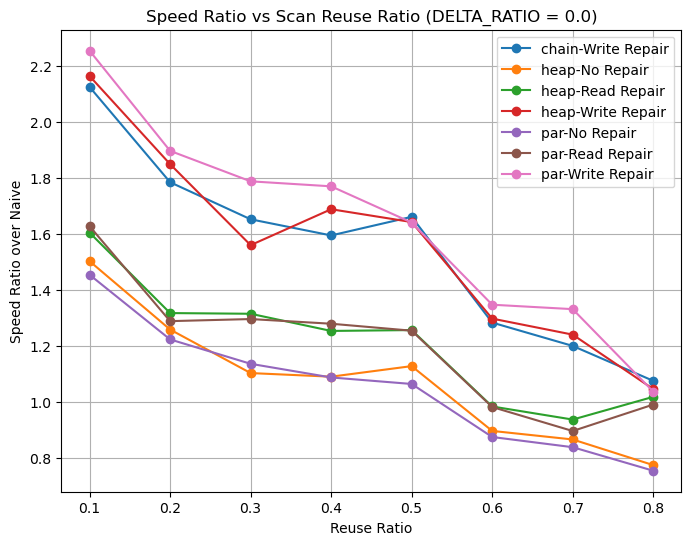

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--warehouse-count', '35', '--txn-update-ratio', '0.3', '--txn-scan-ratio', '0.5', '--txn-gc-ratio', '0.03', '--scan-reuse-ratio', '0.1', '--txn-probe-ratio', '0.06999999999999995', '--txn-delta-ratio', '0.1', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.3)
Transactions Probe ratio: Some(0.06999999999999995)
Transactions Scan ratio: Some(0.5)
Transactions Delta Scan ratio: Some(0.1)
----------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,DeltaScan,7258.112958
1,chain,No Repair,GbgCollect,0.915928
2,chain,No Repair,HistoryScan,1315.759751
3,chain,No Repair,InitLoad,737.634110
4,chain,No Repair,MarkTs,0.000000
5,chain,No Repair,Probe,574.311869
6,chain,No Repair,RecentScan,18431.364141
7,chain,No Repair,Update,1871.219641
8,chain,Read Repair,DeltaScan,7290.592207
9,chain,Read Repair,GbgCollect,0.875286


,tx_type,count,percentage
0,DeltaScan,6,6.382979
1,GbgCollect,2,2.127660
2,HistoryScan,2,2.127660
3,InitLoad,1,1.063830
4,MarkTs,31,32.978723
5,Probe,4,4.255319
6,RecentScan,28,29.787234
7,Update,20,21.276596


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--warehouse-count', '35', '--txn-update-ratio', '0.3', '--txn-scan-ratio', '0.5', '--txn-gc-ratio', '0.03', '--scan-reuse-ratio', '0.2', '--txn-probe-ratio', '0.06999999999999995', '--txn-delta-ratio', '0.1', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.3)
Transactions Probe ratio: Some(0.06999999999999995)
Transactions Scan ratio: Some(0.5)
Transactions Delta Scan ratio: Some(0.1)
----------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,DeltaScan,7037.947647
1,chain,No Repair,GbgCollect,0.894544
2,chain,No Repair,HistoryScan,4594.802754
3,chain,No Repair,InitLoad,736.346973
4,chain,No Repair,MarkTs,0.000000
5,chain,No Repair,Probe,590.712359
6,chain,No Repair,RecentScan,14895.211519
7,chain,No Repair,Update,1883.276637
8,chain,Read Repair,DeltaScan,6970.954241
9,chain,Read Repair,GbgCollect,0.942807


...

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,DeltaScan,7355.849244
1,chain,No Repair,GbgCollect,0.925494
2,chain,No Repair,HistoryScan,15777.063810
3,chain,No Repair,InitLoad,812.035794
4,chain,No Repair,MarkTs,0.000000
5,chain,No Repair,Probe,580.418157
6,chain,No Repair,RecentScan,3956.868721
7,chain,No Repair,Update,1912.675291
8,chain,Read Repair,DeltaScan,7388.196589
9,chain,Read Repair,GbgCollect,0.907086


,tx_type,count,percentage
0,DeltaScan,6,8.333333
1,GbgCollect,2,2.777778
2,HistoryScan,24,33.333333
3,InitLoad,1,1.388889
4,MarkTs,9,12.500000
5,Probe,4,5.555556
6,RecentScan,6,8.333333
7,Update,20,27.777778


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--warehouse-count', '35', '--txn-update-ratio', '0.3', '--txn-scan-ratio', '0.5', '--txn-gc-ratio', '0.03', '--scan-reuse-ratio', '0.8', '--txn-probe-ratio', '0.06999999999999995', '--txn-delta-ratio', '0.1', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.3)
Transactions Probe ratio: Some(0.06999999999999995)
Transactions Scan ratio: Some(0.5)
Transactions Delta Scan ratio: Some(0.1)
----------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,DeltaScan,7305.966949
1,chain,No Repair,GbgCollect,0.887850
2,chain,No Repair,HistoryScan,17989.548693
3,chain,No Repair,InitLoad,753.577180
4,chain,No Repair,MarkTs,0.000000
5,chain,No Repair,Probe,570.348948
6,chain,No Repair,RecentScan,1974.362944
7,chain,No Repair,Update,1856.128418
8,chain,Read Repair,DeltaScan,7515.542704
9,chain,Read Repair,GbgCollect,0.889931


,tx_type,count,percentage
0,DeltaScan,6,8.695652
1,GbgCollect,2,2.898551
2,HistoryScan,27,39.130435
3,InitLoad,1,1.449275
4,MarkTs,6,8.695652
5,Probe,4,5.797101
6,RecentScan,3,4.347826
7,Update,20,28.985507


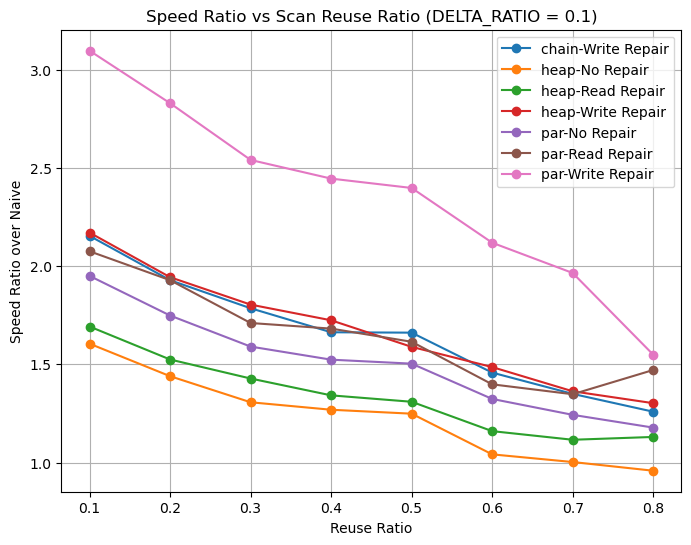

In [11]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")
TITLE = "(UNIFORM-ANALYTICAL) REUSE_OF_TIME"

TXN_UPDATE_RATIO = 0.3
TXN_SCAN_RATIO = 0.5
TXN_GC_RATIO = 0.03
BASE_ARGS = [
    "--txn-count", "60",  
    "--update-ratio", "0.003",
    "--probe-ratio", "0.0001",
    "--warehouse-count", "35", # linear to base table size
    "--txn-update-ratio", str(TXN_UPDATE_RATIO),
    "--txn-scan-ratio", str(TXN_SCAN_RATIO),
    "--txn-gc-ratio", str(TXN_GC_RATIO)
]


REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap", "par", "chain"] #, "par", "chain"
REUSE_CONFIGS = ["0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8"] # , "0.4", "0.8"

from bench_script_functions import run_and_collect, display_all_txns
TRANSACTIONAL_TX_TYPE = ['InitLoad', 'Update']
ANALYTICAL_TX_TYPE = ['Probe', 'Scan', 'DeltaScan']

def get_avg(df):
    # display(df)
    table_types = sorted(df['table_type'].unique())
    repair_types = ["No Repair", "Read Repair", "Write Repair"]
    tx_type_groups = ["DeltaScan"]
    groups = []
    for table_type in table_types:
        if table_type in ['naive', 'chain']:
            groups.append((table_type, 'Write Repair'))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))
    
    durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]
        
        # DeltaScan only average
        # scan_vals = df_group['duration_ms'].values
        # avg_delta_scan = scan_vals.sum()
        # display(df_group)
        scan_vals = df_group['duration_ms'].sum()
        durations.append((table_type, repair_type, scan_vals)) # table_type, repair_type, avg_duration

        # display(df_group)
    return durations

# get ratio over base_type
def get_ratio(avg, base_type, scan_reuse_ratio):
    result = []
    ratio_col_name = f'speed_ratio_over_{base_type}'
    base = None
    for (table_type, repair_type, avg_dur) in avg:
        if table_type in [base_type]:
            base = avg_dur
    
    for (table_type, repair_type, avg_dur) in avg:
        if table_type not in [base_type]:
            result.append({"scan_reuse_ratio": scan_reuse_ratio, "table_type": table_type, "repair_type": repair_type, ratio_col_name: base/ avg_dur})

    df_res = pd.DataFrame(result)
    return df_res

def run_and_draw(txn_delta_ratio):
    assert ((1.0 - TXN_UPDATE_RATIO - TXN_SCAN_RATIO) > (txn_delta_ratio - 1e-6))
    delta_and_probe_ratio = 1.0 - TXN_UPDATE_RATIO - TXN_SCAN_RATIO - TXN_GC_RATIO
    txn_probe_ratio = delta_and_probe_ratio - txn_delta_ratio
    appended_args = [
        "--txn-probe-ratio", str(txn_probe_ratio),
        "--txn-delta-ratio", str(txn_delta_ratio)
    ]
    df_ratio = pd.DataFrame()
    df_list = []
    last_df = None
    for scan_reuse_ratio in REUSE_CONFIGS:
        NEW_ARGS = BASE_ARGS.copy()
        NEW_ARGS += ["--scan-reuse-ratio", scan_reuse_ratio]
        NEW_ARGS += appended_args
        
        df = run_and_collect(BIN, TABLE_TYPES, NEW_ARGS, REPEAT)

        # Display the resulting DataFrame
        pd.set_option('display.max_rows', None)
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', None)
        pd.set_option('display.max_colwidth', None)
        result = df.groupby(["table_type", "repair_type", "tx_type"])["duration_ms"].sum().reset_index()
        df_avg = get_avg(result)
        # print(aa)
        ratio = get_ratio(df_avg, 'naive', scan_reuse_ratio)
        df_ratio = pd.concat([df_ratio, ratio], ignore_index=True)
        display(result)
        df_list.append(result)
        display_all_txns(df)


    df = df_ratio.sort_values(by="scan_reuse_ratio")
    df.to_csv(f'output/{TITLE}_deltaRatio{txn_delta_ratio}_result.csv', index=False)
    # (table_type, repair_type) 
    plt.figure(figsize=(8,6))
    for (table, repair), group in df.groupby(["table_type", "repair_type"]):
        plt.plot(group["scan_reuse_ratio"], group["speed_ratio_over_naive"], 
                marker='o', label=f"{table}-{repair}")

    plt.xlabel("Reuse Ratio")
    plt.ylabel("Speed Ratio over Naive")
    plt.title(f"Speed Ratio vs Scan Reuse Ratio (DELTA_RATIO = {txn_delta_ratio})")
    plt.legend()
    plt.grid(True)
    plt.show()
run_and_draw(txn_delta_ratio=0.0)
run_and_draw(txn_delta_ratio=0.1)
